# 06 — Driving Risk Analysis

Analyze YOLO object detections to estimate potential driving risks based on object type, position, size, and location within the driving scene.

### Objectives
- Load the trained YOLO26s model
- Run object detection on driving images
- Extract bounding box and object information
- Calculate object center positions and relative sizes
- Define an approximate driving risk zone
- Develop a simple and explainable risk scoring method
- Classify detected objects into different risk levels
- Visualize driving risks on road scenes

### Project Roadmap
**Dataset Exploration → Data Preparation → YOLO Training → Evaluation → YOLO Inference → Driving Risk Analysis**

> **Current Stage:** Driving Risk Analysis

## 1. Imports and Configuration

### Required Libraries

Import the libraries required for path handling, data processing, visualization, and YOLO object detection.

In [1]:
# Path handling
from pathlib import Path

# Data handling
import pandas as pd
import numpy as np

# Image processing and visualization
import matplotlib.pyplot as plt

# YOLO model
from ultralytics import YOLO

# Display images inside the notebook
from IPython.display import Image, display

%matplotlib inline

### Configuration

Define the model path, test image directory, and inference settings used throughout the driving risk analysis.

In [2]:
# Project paths
BEST_MODEL_PATH = Path("../runs/runs/yolo26s_main/weights/best.pt")
TEST_IMAGES_DIR = Path("../data/bdd100k/images/100k/test")

# Inference settings
IMG_SIZE = 512
CONF_THRESHOLD = 0.20
DEVICE = 0

print("Model exists:", BEST_MODEL_PATH.exists())
print("Test images directory exists:", TEST_IMAGES_DIR.exists())

Model exists: True
Test images directory exists: True


## 2. Load the Trained YOLO Model

Load the best YOLO26s checkpoint obtained during training and use it for object detection and driving risk analysis.

In [3]:
# Load the best trained YOLO26s model
model = YOLO(BEST_MODEL_PATH)

print("Best YOLO26s model loaded successfully.")

Best YOLO26s model loaded successfully.


## 3. Load a Test Driving Image

Select an unseen driving image from the BDD100K test dataset and prepare it for object detection and risk analysis.

Number of test images: 20000
Selected image: cabc30fc-e7726578.jpg


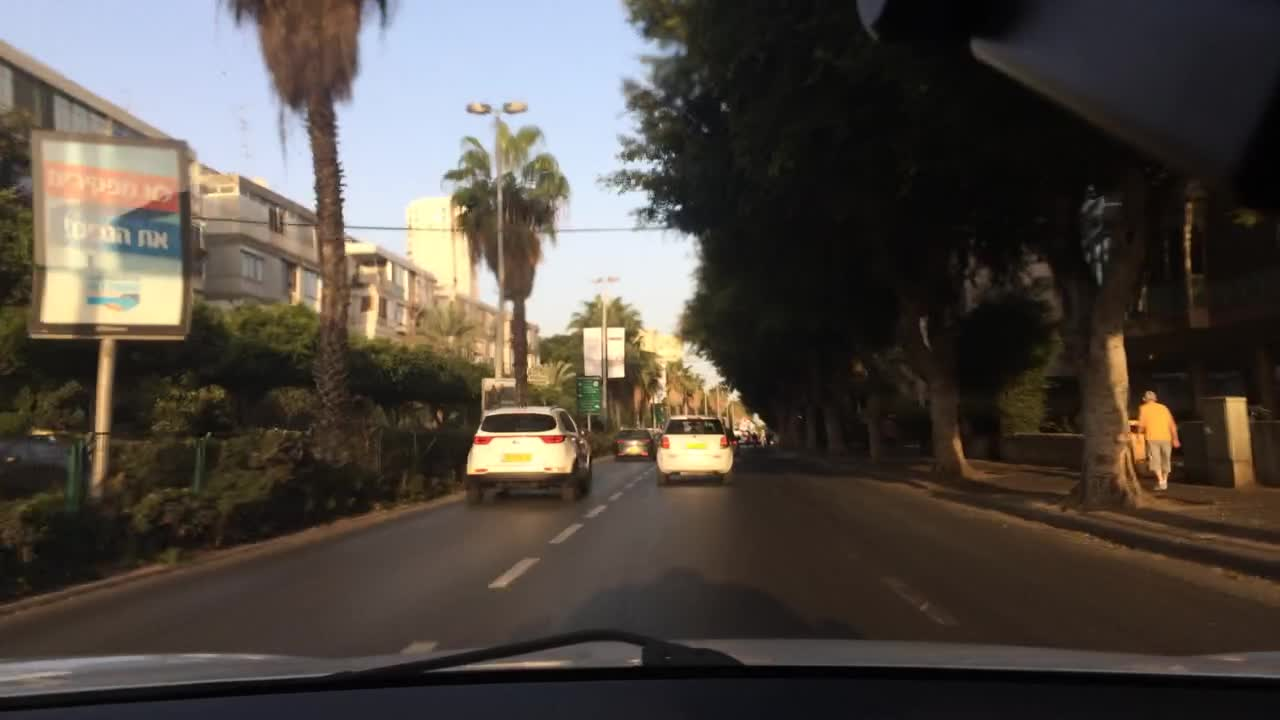

In [4]:
# Find all test images
test_images = list(TEST_IMAGES_DIR.glob("*.jpg"))

print("Number of test images:", len(test_images))

# Select the first test image
test_image = test_images[0]

print("Selected image:", test_image.name)

# Display the selected driving image
display(
    Image(
        filename=str(test_image),
        width=800
    )
)

## 4. Run Object Detection

Run the trained YOLO26s model on the selected driving image to detect road objects that will be used for driving risk analysis.

In [5]:
# Run YOLO object detection
results = model.predict(
    source=str(test_image),
    imgsz=IMG_SIZE,
    conf=CONF_THRESHOLD,
    device=DEVICE,
    verbose=False
)

# Get the first prediction result
result = results[0]

print("Object detection completed successfully.")
print("Number of detected objects:", len(result.boxes))

Object detection completed successfully.
Number of detected objects: 6


## 5. Extract Detection Information

Extract the detected object's class, confidence score, and bounding box coordinates from the YOLO predictions and organize them into a structured table.

In [6]:
# Extract detection information
boxes = result.boxes.xyxy.cpu().numpy()
class_ids = result.boxes.cls.cpu().numpy().astype(int)
confidence_scores = result.boxes.conf.cpu().numpy()

# Store detections in a list
detections = []

for box, class_id, confidence in zip(
    boxes,
    class_ids,
    confidence_scores
):
    x1, y1, x2, y2 = box

    detections.append({
        "class": result.names[class_id],
        "confidence": confidence,
        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2
    })

# Convert detections to a DataFrame
detections_df = pd.DataFrame(detections)

detections_df

,class,confidence,x1,y1,x2,y2
0,car,0.936918,463.898499,403.618896,594.766602,504.917725
1,car,0.908348,654.901001,413.106262,735.491028,487.106506
2,car,0.843597,612.476746,426.745239,656.102173,461.861084
3,person,0.724197,1130.047729,387.565247,1182.445190,496.714355
4,traffic sign,0.547262,574.722229,376.520447,604.111633,413.804596
5,traffic sign,0.320748,582.276001,325.749756,626.225403,377.939301


## 6. Spatial Analysis

Analyze the spatial properties of each detected object by calculating its center position, bounding box dimensions, and relative size within the driving image.

### 6.1 Object Center Position

Calculate the center coordinates of each detected object's bounding box.

In [7]:
# Calculate the center position of each bounding box
detections_df["center_x"] = (
    detections_df["x1"] + detections_df["x2"]
) / 2

detections_df["center_y"] = (
    detections_df["y1"] + detections_df["y2"]
) / 2

detections_df[
    ["class", "confidence", "center_x", "center_y"]
]

,class,confidence,center_x,center_y
0,car,0.936918,529.332520,454.268311
1,car,0.908348,695.196045,450.106384
2,car,0.843597,634.289429,444.303162
3,person,0.724197,1156.246460,442.139801
4,traffic sign,0.547262,589.416931,395.162537
5,traffic sign,0.320748,604.250732,351.844543


### 6.2 Bounding Box Size

Calculate the width, height, and area of each detected object's bounding box to estimate its relative size within the driving scene.

In [8]:
# Calculate bounding box width and height
detections_df["box_width"] = (
    detections_df["x2"] - detections_df["x1"]
)

detections_df["box_height"] = (
    detections_df["y2"] - detections_df["y1"]
)

# Calculate bounding box area
detections_df["box_area"] = (
    detections_df["box_width"] * detections_df["box_height"]
)

detections_df[
    ["class", "box_width", "box_height", "box_area"]
]

,class,box_width,box_height,box_area
0,car,130.868103,101.298828,13256.785156
1,car,80.590027,74.000244,5963.681641
2,car,43.625427,35.115845,1531.943726
3,person,52.397461,109.149109,5719.136230
4,traffic sign,29.389404,37.284149,1095.758911
5,traffic sign,43.949402,52.189545,2293.699219


### 6.3 Relative Object Size

Calculate the bounding box area relative to the total image area.

This provides a normalized measure of how much of the driving scene is occupied by each detected object.

In [10]:
# Get the original image dimensions
image_height, image_width = result.orig_shape

# Calculate the total image area
image_area = image_width * image_height

# Calculate relative object size
detections_df["relative_size"] = (
    detections_df["box_area"] / image_area
)

print("Image width:", image_width)
print("Image height:", image_height)

detections_df[
    ["class", "box_area", "relative_size"]
]

Image width: 1280
Image height: 720


,class,box_area,relative_size
0,car,13256.785156,0.014385
1,car,5963.681641,0.006471
2,car,1531.943726,0.001662
3,person,5719.136230,0.006206
4,traffic sign,1095.758911,0.001189
5,traffic sign,2293.699219,0.002489


## 7. Define the Driving Risk Zone

Define an approximate driving risk zone in front of the vehicle.

Objects located inside or near this region may require more attention because they are positioned closer to the vehicle's expected driving path.

> This risk zone is a simplified image-based approximation and does not represent the exact physical lane or real-world distance.

In [11]:
# Define the approximate driving risk zone
risk_zone_left = image_width * 0.30
risk_zone_right = image_width * 0.70
risk_zone_top = image_height * 0.45
risk_zone_bottom = image_height

print("Risk zone:")
print("Left:", risk_zone_left)
print("Right:", risk_zone_right)
print("Top:", risk_zone_top)
print("Bottom:", risk_zone_bottom)

Risk zone:
Left: 384.0
Right: 896.0
Top: 324.0
Bottom: 720


### 7.1 Visualize the Driving Risk Zone

Visualize the approximate driving risk zone on the selected image to understand which part of the road scene is considered more relevant for risk analysis.

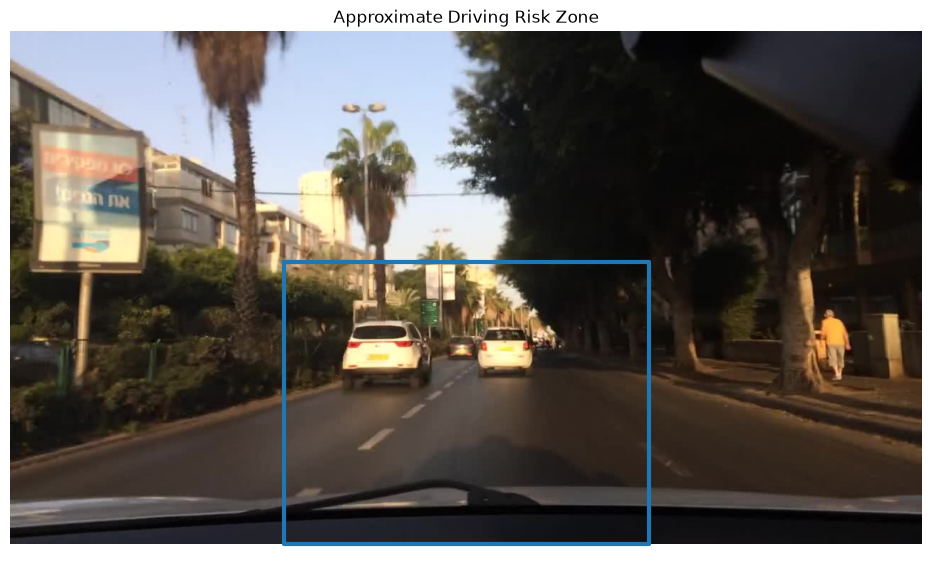

In [12]:
# Load the original image
image = plt.imread(test_image)

# Display the image
plt.figure(figsize=(12, 7))
plt.imshow(image)

# Draw the driving risk zone
plt.plot(
    [risk_zone_left, risk_zone_right, risk_zone_right, risk_zone_left, risk_zone_left],
    [risk_zone_top, risk_zone_top, risk_zone_bottom, risk_zone_bottom, risk_zone_top],
    linewidth=3
)

plt.title("Approximate Driving Risk Zone")
plt.axis("off")
plt.show()

### 7.2 Identify Objects Inside the Risk Zone

Determine whether the center point of each detected object is located inside the approximate driving risk zone.

In [13]:
# Check whether each object's center is inside the risk zone
detections_df["in_risk_zone"] = (
    (detections_df["center_x"] >= risk_zone_left) &
    (detections_df["center_x"] <= risk_zone_right) &
    (detections_df["center_y"] >= risk_zone_top) &
    (detections_df["center_y"] <= risk_zone_bottom)
)

detections_df[
    ["class", "center_x", "center_y", "in_risk_zone"]
]

,class,center_x,center_y,in_risk_zone
0,car,529.332520,454.268311,True
1,car,695.196045,450.106384,True
2,car,634.289429,444.303162,True
3,person,1156.246460,442.139801,False
4,traffic sign,589.416931,395.162537,True
5,traffic sign,604.250732,351.844543,True


## 8. Risk Score Calculation

Calculate an explainable risk score for each detected object by combining multiple image-based factors.

The risk score will consider:

- Object type
- Position relative to the driving risk zone
- Relative bounding box size
- Detection confidence

> The calculated score is a simplified image-based risk indicator. It does not represent the actual probability of a collision or a real-world safety assessment.

### 8.1 Object Type Weight

Assign a base risk weight to each object class.

Dynamic road users such as cars, trucks, buses, pedestrians, riders, bicycles, and motorcycles receive higher weights because their position and movement may be more relevant to driving risk.

Static road infrastructure such as traffic signs and traffic lights receives a lower base weight.

These weights are heuristic values designed for this project and are not real-world collision probabilities.

In [14]:
# Define heuristic risk weights for each object class
class_risk_weights = {
    "car": 1.0,
    "truck": 1.0,
    "bus": 1.0,
    "train": 1.0,
    "person": 1.0,
    "rider": 1.0,
    "bike": 1.0,
    "motor": 1.0,
    "traffic light": 0.3,
    "traffic sign": 0.2
}

# Assign a risk weight to each detected object
detections_df["class_weight"] = (
    detections_df["class"].map(class_risk_weights)
)

detections_df[
    ["class", "in_risk_zone", "relative_size", "class_weight"]
]

,class,in_risk_zone,relative_size,class_weight
0,car,True,0.014385,1.0
1,car,True,0.006471,1.0
2,car,True,0.001662,1.0
3,person,False,0.006206,1.0
4,traffic sign,True,0.001189,0.2
5,traffic sign,True,0.002489,0.2


### 8.2 Position Weight

Assign a position weight based on whether the center of the detected object is located inside the approximate driving risk zone.

Objects inside the risk zone receive a higher position weight because they are closer to the estimated driving path.

In [15]:
# Assign a position weight based on the risk zone
detections_df["position_weight"] = np.where(
    detections_df["in_risk_zone"],
    1.0,
    0.3
)

detections_df[
    ["class", "in_risk_zone", "position_weight"]
]

,class,in_risk_zone,position_weight
0,car,True,1.0
1,car,True,1.0
2,car,True,1.0
3,person,False,0.3
4,traffic sign,True,1.0
5,traffic sign,True,1.0


### 8.3 Size Weight

Convert the relative bounding box size into a normalized size weight.

Larger detected objects receive a higher size weight because they occupy a larger portion of the image.

> Bounding box size is only an image-based approximation and does not directly represent the real-world distance between the object and the vehicle.

In [16]:
# Convert relative object size into a normalized size weight
detections_df["size_weight"] = np.clip(
    detections_df["relative_size"] / 0.05,
    0.0,
    1.0
)

detections_df[
    ["class", "relative_size", "size_weight"]
]

,class,relative_size,size_weight
0,car,0.014385,0.287691
1,car,0.006471,0.129420
2,car,0.001662,0.033245
3,person,0.006206,0.124113
4,traffic sign,0.001189,0.023779
5,traffic sign,0.002489,0.049776


### 8.4 Final Risk Score

Combine object type, position, relative size, and detection confidence into a single normalized risk score.

The score is designed as an explainable heuristic for this project and ranges approximately from 0 to 1.

A higher score indicates that the detected object may require more attention within the current driving scene.

In [17]:
# Calculate the final risk score
detections_df["risk_score"] = (
    0.30 * detections_df["class_weight"] +
    0.35 * detections_df["position_weight"] +
    0.25 * detections_df["size_weight"] +
    0.10 * detections_df["confidence"]
)

# Keep the score between 0 and 1
detections_df["risk_score"] = np.clip(
    detections_df["risk_score"],
    0.0,
    1.0
)

detections_df[
    [
        "class",
        "class_weight",
        "position_weight",
        "size_weight",
        "confidence",
        "risk_score"
    ]
]

,class,class_weight,position_weight,size_weight,confidence,risk_score
0,car,1.0,1.0,0.287691,0.936918,0.815614
1,car,1.0,1.0,0.129420,0.908348,0.773190
2,car,1.0,1.0,0.033245,0.843597,0.742671
3,person,1.0,0.3,0.124113,0.724197,0.508448
4,traffic sign,0.2,1.0,0.023779,0.547262,0.470671
5,traffic sign,0.2,1.0,0.049776,0.320748,0.454519


## 9. Risk Level Classification

Convert the numerical risk score into human-readable risk levels.

For this initial heuristic system, detected objects are classified into three categories:

- **LOW** — lower attention priority
- **MEDIUM** — moderate attention priority
- **HIGH** — higher attention priority

> These categories represent relative attention levels within this project and are not real-world collision risk probabilities.

In [18]:
# Convert risk scores into risk levels
def classify_risk(score):
    if score >= 0.70:
        return "HIGH"
    elif score >= 0.40:
        return "MEDIUM"
    else:
        return "LOW"


detections_df["risk_level"] = (
    detections_df["risk_score"].apply(classify_risk)
)

detections_df[
    ["class", "confidence", "risk_score", "risk_level"]
]

,class,confidence,risk_score,risk_level
0,car,0.936918,0.815614,HIGH
1,car,0.908348,0.773190,HIGH
2,car,0.843597,0.742671,HIGH
3,person,0.724197,0.508448,MEDIUM
4,traffic sign,0.547262,0.470671,MEDIUM
5,traffic sign,0.320748,0.454519,MEDIUM


## 10. Risk Visualization

Visualize the driving risk analysis directly on the road scene.

Each detected object is displayed with its bounding box, class label, risk score, and risk level.

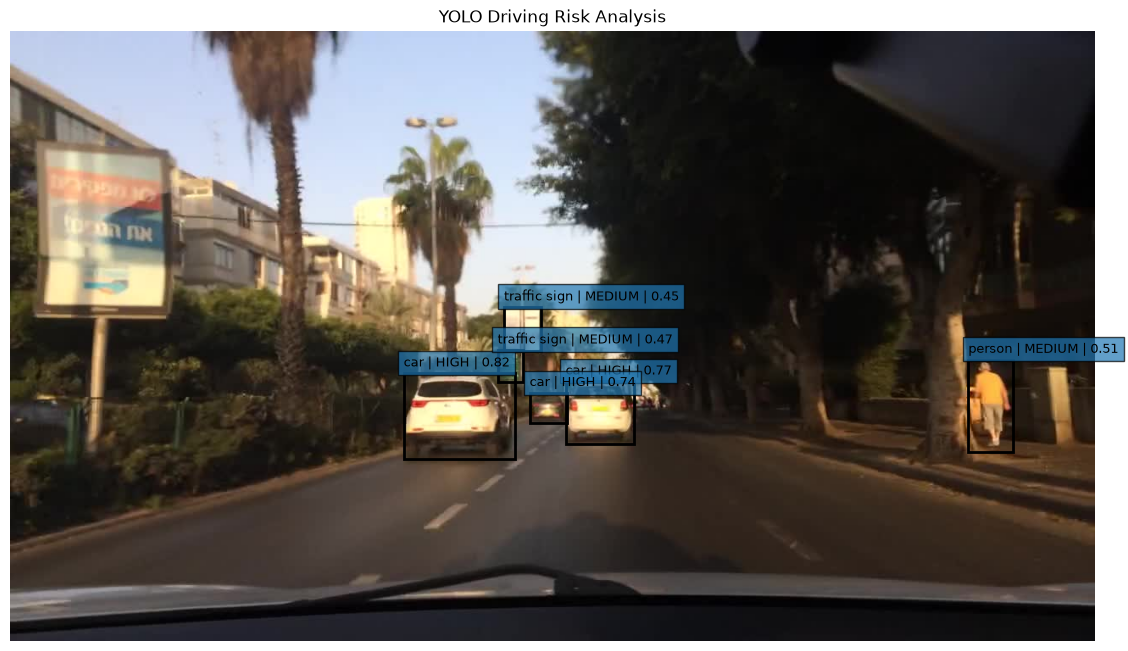

In [19]:
# Display the original driving image
plt.figure(figsize=(14, 8))
plt.imshow(image)

# Draw each detected object
for _, row in detections_df.iterrows():

    x1 = row["x1"]
    y1 = row["y1"]
    x2 = row["x2"]
    y2 = row["y2"]

    # Draw bounding box
    rectangle = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2
    )

    plt.gca().add_patch(rectangle)

    # Create risk label
    label = (
        f'{row["class"]} | '
        f'{row["risk_level"]} | '
        f'{row["risk_score"]:.2f}'
    )

    # Display label above the bounding box
    plt.text(
        x1,
        y1 - 8,
        label,
        fontsize=9,
        bbox=dict(alpha=0.7)
    )

plt.title("YOLO Driving Risk Analysis")
plt.axis("off")
plt.show()

## 11. Test on Multiple Driving Images

Apply the driving risk analysis pipeline to multiple unseen test images.

This step helps evaluate whether the heuristic risk analysis behaves consistently across different driving scenes.

### 11.1 Create the Risk Analysis Function

Create a reusable function that applies the complete driving risk analysis pipeline to a YOLO detection result.

The function calculates spatial features, heuristic risk weights, the final risk score, and the corresponding risk level for every detected object.

In [22]:
def analyze_driving_risk(result):

    # Extract YOLO detections
    boxes = result.boxes.xyxy.cpu().numpy()
    class_ids = result.boxes.cls.cpu().numpy().astype(int)
    confidence_scores = result.boxes.conf.cpu().numpy()

    # Get original image dimensions
    image_height, image_width = result.orig_shape
    image_area = image_width * image_height

    detections = []

    for box, class_id, confidence in zip(
        boxes, class_ids, confidence_scores
    ):
        x1, y1, x2, y2 = box

        # Spatial information
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2

        box_width = x2 - x1
        box_height = y2 - y1
        box_area = box_width * box_height

        relative_size = box_area / image_area

        # Check whether object center is inside risk zone
        in_risk_zone = (
            (center_x >= image_width * 0.30) and
            (center_x <= image_width * 0.70) and
            (center_y >= image_height * 0.45)
        )

        # Risk factors
        class_name = result.names[class_id]
        class_weight = class_risk_weights.get(class_name, 0.5)

        position_weight = 1.0 if in_risk_zone else 0.3

        size_weight = np.clip(
            relative_size / 0.05,
            0.0,
            1.0
        )

        # Final risk score
        risk_score = (
            0.30 * class_weight +
            0.35 * position_weight +
            0.25 * size_weight +
            0.10 * confidence
        )

        risk_score = np.clip(risk_score, 0.0, 1.0)

        # Risk level
        risk_level = classify_risk(risk_score)

        detections.append({
            "class": class_name,
            "confidence": confidence,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "center_x": center_x,
            "center_y": center_y,
            "relative_size": relative_size,
            "in_risk_zone": in_risk_zone,
            "risk_score": risk_score,
            "risk_level": risk_level
        })

    return pd.DataFrame(detections)

### 11.2 Run Risk Analysis on Multiple Images

Run YOLO detection and the driving risk analysis function on multiple unseen test images.

For each image, display the detected objects together with their confidence scores, risk scores, and risk levels.

In [21]:
# Select multiple unseen test images
multiple_test_images = test_images[:5]

for i, image_path in enumerate(multiple_test_images):

    # Run YOLO detection
    results = model.predict(
        source=str(image_path),
        imgsz=IMG_SIZE,
        conf=CONF_THRESHOLD,
        device=DEVICE,
        verbose=False
    )

    result = results[0]

    # Run driving risk analysis
    risk_df = analyze_driving_risk(result)

    print(f"\nImage {i + 1}: {image_path.name}")
    display(
        risk_df[
            ["class", "confidence", "risk_score", "risk_level"]
        ]
    )


Image 1: cabc30fc-e7726578.jpg


,class,confidence,risk_score,risk_level
0,car,0.936918,0.815614,HIGH
1,car,0.908348,0.773190,HIGH
2,car,0.843597,0.742671,HIGH
3,person,0.724197,0.508448,MEDIUM
4,traffic sign,0.547262,0.470671,MEDIUM
5,traffic sign,0.320748,0.454519,MEDIUM



Image 2: cabc30fc-eb673c5a.jpg


,class,confidence,risk_score,risk_level
0,car,0.902499,0.547555,MEDIUM
1,car,0.897175,0.744717,HIGH
2,car,0.889576,0.846834,HIGH
3,car,0.831428,0.743636,HIGH
4,car,0.591833,0.712283,HIGH
5,car,0.553753,0.708674,HIGH
6,traffic sign,0.535106,0.225647,LOW
7,truck,0.400383,0.722578,HIGH
8,truck,0.399405,0.695984,MEDIUM
9,car,0.340814,0.690125,MEDIUM



Image 3: cabc30fc-fd79926f.jpg


,class,confidence,risk_score,risk_level
0,car,0.951804,0.995180,HIGH
1,car,0.931723,0.780925,HIGH
2,car,0.870720,0.753318,HIGH
3,person,0.747005,0.503172,MEDIUM
4,person,0.712246,0.492809,MEDIUM
5,car,0.693697,0.548955,MEDIUM
6,person,0.510522,0.494769,MEDIUM
7,rider,0.396594,0.695721,MEDIUM
8,car,0.373788,0.689542,MEDIUM
9,traffic sign,0.365242,0.448674,MEDIUM



Image 4: cabc9045-1b8282ba.jpg


,class,confidence,risk_score,risk_level
0,car,0.852304,0.553375,MEDIUM
1,car,0.817175,0.498405,MEDIUM
2,car,0.814742,0.515439,MEDIUM
3,car,0.791832,0.497611,MEDIUM
4,car,0.763402,0.531316,MEDIUM
5,car,0.700265,0.479653,MEDIUM
6,traffic light,0.641095,0.264653,LOW
7,car,0.592329,0.493859,MEDIUM
8,car,0.537313,0.462051,MEDIUM
9,car,0.535193,0.463573,MEDIUM



Image 5: cabc9045-581f64de.jpg


,class,confidence,risk_score,risk_level
0,traffic sign,0.901855,0.328139,LOW
1,car,0.824576,0.499057,MEDIUM
2,traffic sign,0.617722,0.229818,LOW
3,car,0.610384,0.475377,MEDIUM
4,car,0.586519,0.473460,MEDIUM
5,traffic sign,0.563293,0.250933,LOW
6,traffic light,0.491041,0.245799,LOW
7,car,0.365605,0.450388,MEDIUM
8,traffic light,0.345919,0.231186,LOW
9,car,0.292442,0.439316,MEDIUM


### 11.3 Visualize Risk Analysis on Multiple Images

Visualize the driving risk analysis results for multiple unseen test images.

Each detected object is shown with its bounding box, class name, risk level, and calculated risk score.

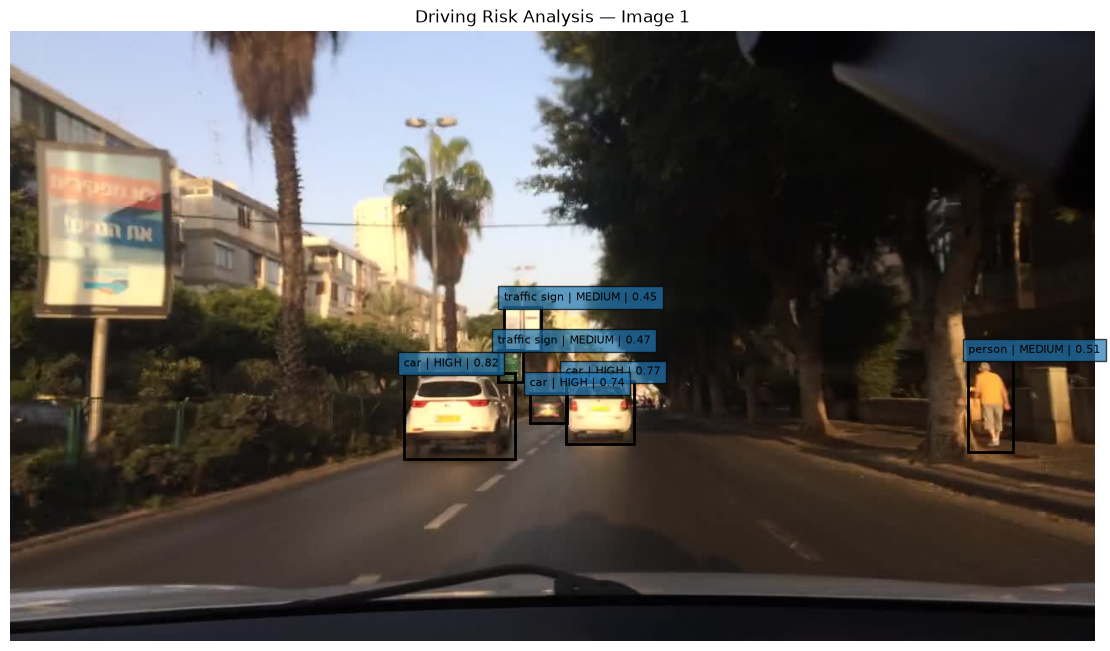

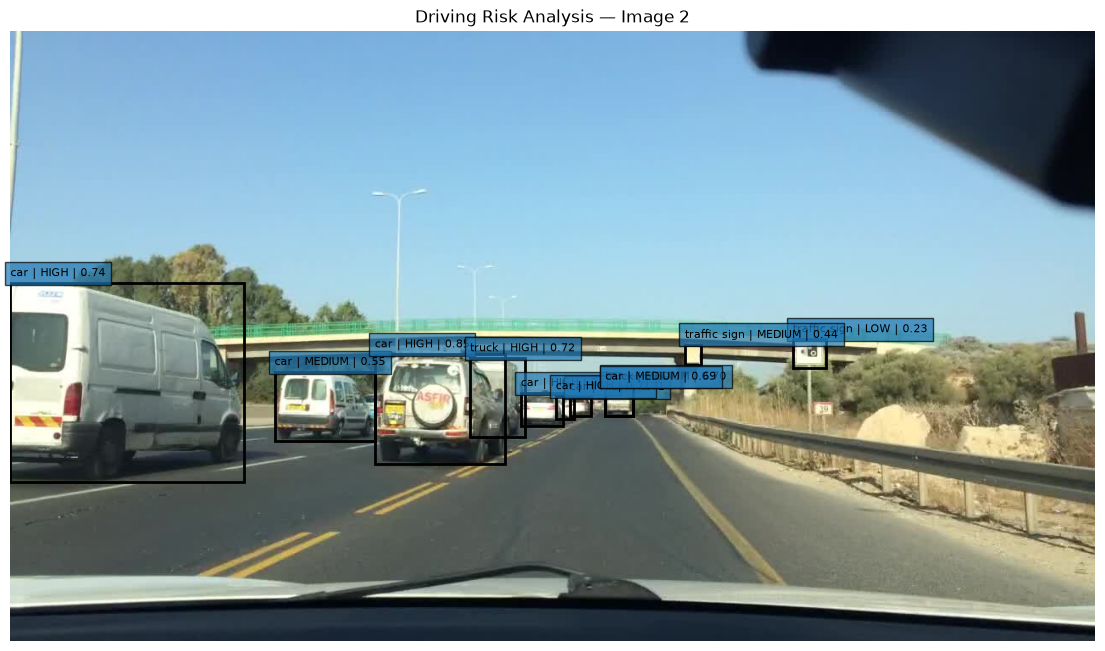

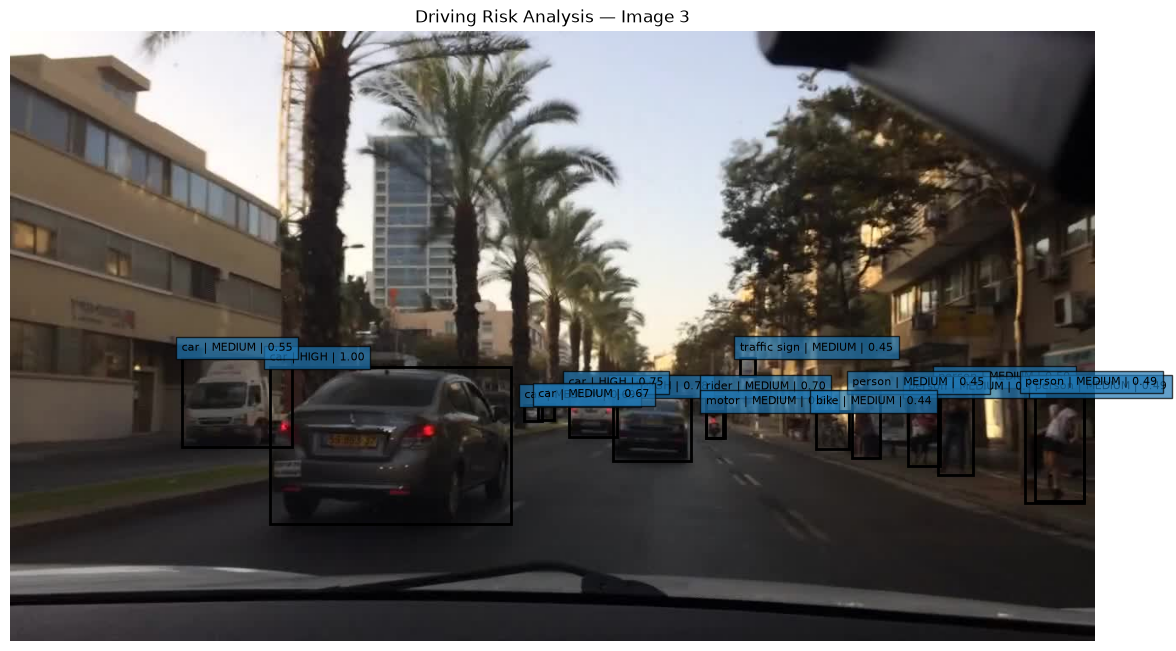

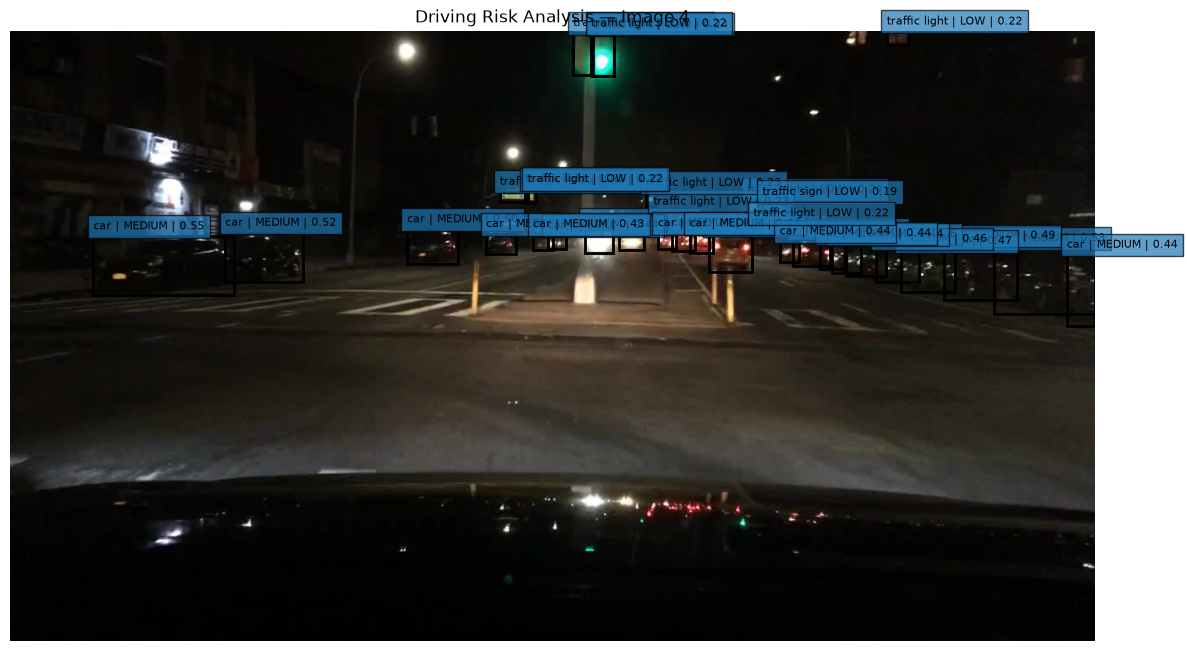

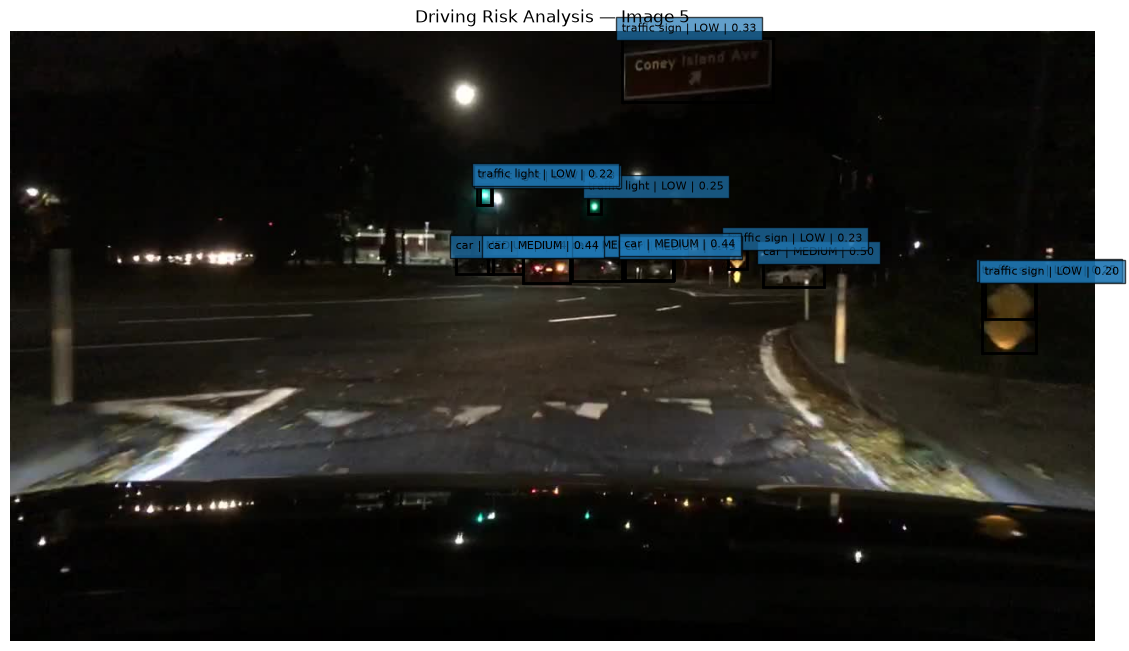

In [23]:
for i, image_path in enumerate(multiple_test_images):

    # Run YOLO detection
    results = model.predict(
        source=str(image_path),
        imgsz=IMG_SIZE,
        conf=CONF_THRESHOLD,
        device=DEVICE,
        verbose=False
    )

    result = results[0]

    # Run driving risk analysis
    risk_df = analyze_driving_risk(result)

    # Load the original image
    image = plt.imread(image_path)

    plt.figure(figsize=(14, 8))
    plt.imshow(image)

    # Draw bounding boxes and risk labels
    for _, row in risk_df.iterrows():

        x1 = row["x1"]
        y1 = row["y1"]
        x2 = row["x2"]
        y2 = row["y2"]

        rectangle = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )

        plt.gca().add_patch(rectangle)

        label = (
            f'{row["class"]} | '
            f'{row["risk_level"]} | '
            f'{row["risk_score"]:.2f}'
        )

        plt.text(
            x1,
            y1 - 8,
            label,
            fontsize=8,
            bbox=dict(alpha=0.7)
        )

    plt.title(f"Driving Risk Analysis — Image {i + 1}")
    plt.axis("off")
    plt.show()

## 12. Conclusion

In this notebook, a simple and explainable driving risk analysis system was developed on top of the trained YOLO26s object detector.

The system:

- Detected road objects using the trained YOLO26s model
- Extracted spatial information from bounding boxes
- Calculated object center positions and relative sizes
- Defined an approximate driving risk zone
- Combined object type, position, size, and detection confidence
- Calculated a heuristic risk score for each detected object
- Classified objects into LOW, MEDIUM, and HIGH risk levels
- Visualized the resulting risk information directly on driving scenes
- Tested the complete risk analysis pipeline on multiple unseen images

### Limitations

The current risk analysis is based only on single images and heuristic rules.

Therefore, the calculated risk score does not represent the actual probability of a collision. The system does not currently estimate real-world distance, vehicle speed, object movement, lane geometry, or time-to-collision.

### Future Improvements

Future versions of the project could include:

- Object tracking across video frames
- Distance estimation
- Lane detection
- Vehicle and pedestrian motion analysis
- Time-to-collision estimation
- More advanced data-driven risk prediction

### Project Pipeline

**BDD100K → Data Preparation → YOLO26s Training → Evaluation → Inference → Driving Risk Analysis**

The complete pipeline now extends object detection into an explainable image-based driving risk analysis system.